# Chapter 41 — Practical Calibration: Gains, Bandpass & Self-Cal

!!! info "Before you start"
    **Prerequisites:** Ch 7 (Why Interferometry), Ch 8 (Aperture Synthesis), Ch 9 (Deconvolution & CLEAN) · **Maths Lab:** [Lab E (Linear Algebra for Calibration)](35_mathslab_calibration.ipynb) · **~50 min** · **Advanced**

This chapter is the *applied companion* to **Maths Lab E (Lab 35)**.
Where Lab E derives the linear-algebra machinery — eigenvectors, SVD,
closure invariants — this chapter walks an end-to-end calibration
workflow on a simulated 8-antenna array: corrupt the data, solve for gains,
correct, verify, and then run a self-calibration loop.
Every line uses `jansky.interferometry` helpers so you can see the physics
in the code.

## The big idea

A real interferometer never measures the true sky visibilities.
What it actually measures is

$$
V^\mathrm{obs}_{ij} \;=\; g_i\,V^\mathrm{true}_{ij}\,g_j^{*} + n_{ij},
$$

where $g_i = a_i\,e^{i\phi_i}$ is antenna $i$'s unknown **complex gain**
(amplitude $a_i$ and phase $\phi_i$), varying with time and frequency, and
$n_{ij}$ is thermal noise on baseline $ij$.
**Calibration is solving for those gains and dividing them out** so
the corrected data approaches $V^\mathrm{true}$.

## Learning goals

By the end of this chapter you will be able to:

- State the radio-interferometer **measurement equation** and explain
  what each factor represents physically.
- Explain why an interferometer cannot recover an **absolute flux scale**
  or a **global phase** without external constraints.
- Perform a complete **gain-calibration** cycle: build a calibrator model,
  solve with StefCal (`solve_gains_stefcal`), correct the data, and assess
  the residual.
- Extend gain-cal to **bandpass calibration**: solve per frequency channel
  to track smooth spectral ripples in the instrument response.
- Implement a **self-calibration loop** (Cornwell & Wilkinson 1981):
  iterate model → gain-solve → correct until convergence.
- Use **closure phase** and **closure amplitude** as gain-immune truth anchors
  throughout and show they are unchanged by the corruptions.


## The history: three papers that made practical calibration possible

### 1. Cornwell & Wilkinson (1981) — self-calibration

> **Cornwell, T. J. & Wilkinson, P. N. (1981).**
> *A new method for making maps with unstable radio interferometers.*
> Monthly Notices of the Royal Astronomical Society **196**, 1067–1086.
> [ADS](https://ui.adsabs.harvard.edu/abs/1981MNRAS.196.1067C)
> · [DOI 10.1093/mnras/196.4.1067](https://doi.org/10.1093/mnras/196.4.1067)

Before self-cal, every radio image was only as good as the prior calibration.
Cornwell & Wilkinson showed that if the sky is bright enough, you can
*bootstrap*: use the current best image as the model, solve the
per-antenna gains against it, correct the data, re-image, and repeat.
Because the gain solve has only $N$ unknowns while $N(N-1)/2$ baselines
constrain them, the redundancy drives the solution to convergence —
self-calibration was born.

### 2. Pearson & Readhead (1984) — closure quantities and VLBI imaging

> **Pearson, T. J. & Readhead, A. C. S. (1984).**
> *Image formation by self-calibration in radio astronomy.*
> Annual Review of Astronomy and Astrophysics **22**, 97–130.
> [ADS](https://ui.adsabs.harvard.edu/abs/1984ARA%26A..22...97P)
> · [DOI 10.1146/annurev.aa.22.090184.000525](https://doi.org/10.1146/annurev.aa.22.090184.000525)

This landmark review established **closure phase** (invariant to per-antenna
phase errors) and **closure amplitude** (invariant to per-antenna gain errors)
as the robust observables of VLBI.  When you cannot calibrate — sparse global
arrays, fast atmosphere — closure quantities carry uncontaminated source
information.  The Event Horizon Telescope still depends on this insight.

### 3. Hamaker, Bregman & Sault (1996) — the full measurement equation

> **Hamaker, J. P., Bregman, J. D. & Sault, R. J. (1996).**
> *Understanding radio polarimetry. I. Mathematical foundations.*
> Astronomy & Astrophysics Supplement Series **117**, 137–147.
> [ADS](https://ui.adsabs.harvard.edu/abs/1996A%26AS..117..137H)

Hamaker et al. cast the entire chain — feed, sky rotation, ionosphere,
bandpass, correlator — as a product of $2\times 2$ Jones matrices (one per
antenna per frequency per time) acting on the Stokes coherency vector.
This **RIME** (Radio Interferometer Measurement Equation) is the formalism
underlying CASA, MeqTrees, and every modern calibration package.
In this chapter we use the scalar gain ($1\times 1$ Jones matrix) — Lab E
discusses the full matrix version.

### StefCal (the solver this chapter uses)

> **Salvini, S. & Wijnholds, S. J. (2014).**
> *Fast gain calibration in radio astronomy using alternating direction implicit
> methods: Analysis and applications.*
> Astronomy & Astrophysics **571**, A97.
> [ADS](https://ui.adsabs.harvard.edu/abs/2014A%26A...571A..97S)
> · [DOI 10.1051/0004-6361/201424487](https://doi.org/10.1051/0004-6361/201424487)

StefCal is an alternating-direction solver: it updates each antenna's gain in
closed form while holding all others fixed, then averages successive iterates
for stability.  `jansky.interferometry.solve_gains_stefcal` is a faithful
minimal implementation of this algorithm.


## The physics (concise — see Lab E for the full linear algebra)

### 3.1 Per-antenna complex gains

The correlation of two antenna voltages $v_i$ and $v_j$ (the **visibility**)
picks up a factor of $g_i$ from arm $i$ and $g_j^{*}$ from arm $j$:

$$
V^\mathrm{obs}_{ij}
\;=\; g_i\,V^\mathrm{true}_{ij}\,g_j^{*} + n_{ij},
\qquad g_i = a_i\,e^{i\phi_i}.
$$

Stacking all baselines in matrix form (see Lab E, §2):

$$
\mathbf{V}^\mathrm{obs} \;=\; G\,\mathbf{V}^\mathrm{true}\,G^{\mathsf H},
\qquad G = \operatorname{diag}(g_1,\dots,g_N).
$$

### 3.2 What an interferometer cannot see: the absolute-scale degeneracy

Multiply every gain by the same constant $c$:
$(c\,g_i)(c\,g_j)^{*} = |c|^2 g_i g_j^{*}$.
Every visibility is scaled by $|c|^2$ — indistinguishable from a change in
the source flux.  Similarly, multiply every gain by $e^{i\alpha}$:
$e^{i\alpha}g_i\,e^{-i\alpha}g_j^{*} = g_i g_j^{*}$.
Every baseline-phase shift cancels.  Consequently:

- The **absolute flux scale** must come from an external calibrator
  (a source of known flux density, e.g. 3C 286).
- A **global phase** is unconstrained; the convention is to rotate so
  $g_0$ is real and positive.

### 3.3 Why calibration is solvable: the counting argument

An $N$-antenna array produces $N(N-1)/2$ baseline measurements per
frequency channel, but needs only $N$ complex gains.
For $N=8$: 28 baselines, 8 gains.
This **28:8 over-determination** is what makes the gain solve stable —
the redundancy averages down thermal noise in the estimates.

### 3.4 Bandpass calibration: $g_i(\nu)$

The gain is not just time-varying; it also varies with frequency — the
**bandpass** $g_i(\nu)$.  Physical causes include passband ripple from
standing waves in feeds and cables, and the frequency response of the
IF chain.  Solving per channel:

$$
V^\mathrm{obs}_{ij,\nu}
\;=\; g_i(\nu)\,V^\mathrm{true}_{ij,\nu}\,g_j^{*}(\nu) + n_{ij,\nu}.
$$

### 3.5 Self-calibration: the Cornwell–Wilkinson loop

When no external calibrator is available (or between calibrator scans),
use the target source itself:

1. Start from a model $\mathbf{V}^\mathrm{model}$ (could be a point source,
   could be the latest CLEAN image).
2. **Gain solve:** $\hat{g} = \text{StefCal}(\mathbf{V}^\mathrm{obs},\,\mathbf{V}^\mathrm{model})$.
3. **Correct:** $\mathbf{V}^\mathrm{cor}_{ij}
   = \mathbf{V}^\mathrm{obs}_{ij} / (\hat{g}_i\,\hat{g}_j^{*})$.
4. **Re-image** $\mathbf{V}^\mathrm{cor}$ → update model → go to 2.

Converges because the redundancy ($N(N-1)/2 \gg N$) means the gains are
over-determined, and the sky's sky-coherence (most emission is compact)
means the image barely changes between the first and final cycles while the
gains settle.  Phase-only self-cal (force $|g_i|=1$) is run first because
it is more stable; amplitude+phase self-cal follows once the phases are good.

### 3.6 Closure quantities: the gain-immune truth anchor

**Closure phase** around a triangle $(i,j,k)$:

$$
\Psi_{ijk}
\;=\; \arg\!\bigl(V_{ij}\,V_{jk}\,V_{ki}\bigr)
\;=\; \arg\!\bigl(V^\mathrm{true}_{ij}\,V^\mathrm{true}_{jk}\,V^\mathrm{true}_{ki}\bigr).
$$

Per-antenna phases cancel around the loop (each $\phi_i$ appears once with
each sign).

**Closure amplitude** over a quadrangle $(i,j,k,l)$:

$$
A_{ijkl}
\;=\; \frac{|V_{ij}|\,|V_{kl}|}{|V_{ik}|\,|V_{jl}|}
\;=\; \frac{|V^\mathrm{true}_{ij}|\,|V^\mathrm{true}_{kl}|}
          {|V^\mathrm{true}_{ik}|\,|V^\mathrm{true}_{jl}|}.
$$

Per-antenna amplitudes cancel.  Both quantities are pure source information —
no gain solver can accidentally corrupt them.


## Setup

All computation runs offline with the base `jansky` environment.
The optional `pyuvdata` real-data block at the end requires
`uv sync --extra formats` and is guarded so the notebook runs cleanly
without it.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings

from jansky import interferometry, plotting
from jansky.interferometry import (
    apply_gains,
    solve_gains_stefcal,
    solve_point_source_gains,
    closure_phase,
    closure_amplitude,
)
from jansky.plotting import use_jansky_style

use_jansky_style()

# One seeded generator drives the whole chapter → reproducible results.
rng = np.random.default_rng(41)

np.set_printoptions(precision=4, suppress=True)
print("jansky interferometry helpers loaded:")
print("  apply_gains, solve_gains_stefcal, solve_point_source_gains,")
print("  closure_phase, closure_amplitude")

jansky interferometry helpers loaded:
  apply_gains, solve_gains_stefcal, solve_point_source_gains,
  closure_phase, closure_amplitude


## Section 4 — Gain calibration on a simulated array

### 4a. Build the (corrupted) observations

We simulate an 8-antenna array observing a single **unresolved point source**
(a calibrator) of unit flux.  The true visibility matrix for a point source
is $V^\mathrm{true}_{ij} = 1$ for all $i \ne j$ (we ignore auto-correlations
on the diagonal).  We then corrupt with random complex gains via `apply_gains`.

The figure below shows the visibility amplitude matrix before and after
corruption — note how every row and column is uniformly scaled, the
"stripe" signature of antenna-based errors (see Lab E, §2).


In [2]:
N_ANT = 8
# True visibility: all baselines see the same point source = outer(1,1).
V_true_cal = np.ones((N_ANT, N_ANT), dtype=complex)

# Random complex gains: amplitudes ~ Uniform(0.5, 2.0), phases ~ Uniform(-π, π).
amp_true = rng.uniform(0.5, 2.0, size=N_ANT)
phase_true = rng.uniform(-np.pi, np.pi, size=N_ANT)
g_true = amp_true * np.exp(1j * phase_true)

# Corrupt via the forward measurement equation: V_obs = diag(g) V_true diag(g)^H.
V_obs_cal = apply_gains(V_true_cal, g_true)

print("True gains |g|:")
print("  ", np.round(amp_true, 3))
print("True gain phases (deg):")
print("  ", np.round(np.degrees(phase_true), 1))

# Confirm the entry-by-entry formula V_obs[i,j] = g[i]*conj(g[j])*V_true[i,j].
check = np.outer(g_true, np.conj(g_true)) * V_true_cal
print("\nmax |apply_gains - outer product|:", np.abs(V_obs_cal - check).max())

True gains |g|:
   [1.931 1.652 0.689 1.74  1.774 1.025 1.267 1.404]
True gain phases (deg):
   [-58.   43.9  83.7 130.  -58.4 -25.5  33.9 171.2]

max |apply_gains - outer product|: 0.0


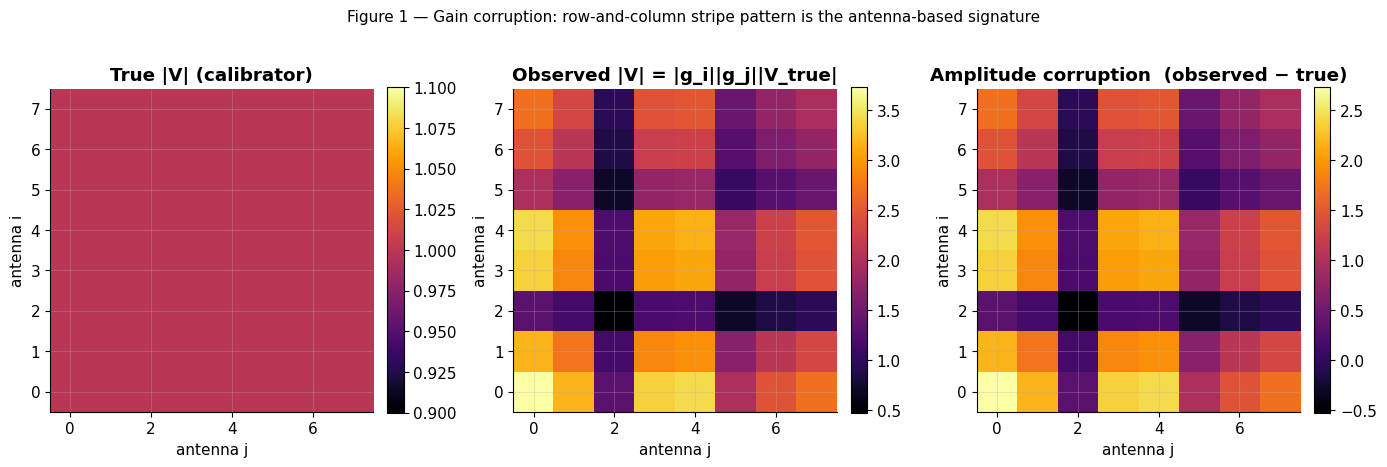

In [3]:
# ── Figure 1: Corrupted vs true visibility amplitude matrix ──────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

for ax, M, title in [
    (axes[0], np.abs(V_true_cal), "True |V| (calibrator)"),
    (axes[1], np.abs(V_obs_cal), "Observed |V| = |g_i||g_j||V_true|"),
    (axes[2], np.abs(V_obs_cal) - np.abs(V_true_cal), "Amplitude corruption  (observed − true)"),
]:
    im = ax.imshow(M, cmap="inferno")
    ax.set_title(title)
    ax.set_xlabel("antenna j")
    ax.set_ylabel("antenna i")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle(
    "Figure 1 — Gain corruption: row-and-column stripe pattern is the antenna-based signature",
    y=1.02,
    fontsize=11,
)
fig.tight_layout()
plt.show()

**Figure 1.** Left: true calibrator visibility amplitude (all ones for a unit
point source). Middle: corrupted amplitudes — each row $i$ is scaled by $|g_i|$
and each column $j$ by $|g_j|$, producing the characteristic "striped" pattern.
Right: the amplitude correction needed. Identifying this antenna-based structure
is what makes gain-cal tractable: only $N=8$ unknowns from 28 baseline equations.


### 4b. Recover gains with StefCal and correct the data

`solve_gains_stefcal(V_obs, V_model)` returns the per-antenna complex gains
$\hat{g}$ that minimise the weighted residual between `V_obs` and
`V_model` (here the unit point-source model $V_{ij}^\mathrm{model}=1$).
Because the gains are defined only up to a **global phase** (see §3.2 and
Lab E §3), both the true gains and the recovered gains are referenced by
rotating $g_0$ to be real and positive before comparing.


In [4]:
# ── Solve for gains with StefCal ─────────────────────────────────────────────
V_model_cal = np.ones((N_ANT, N_ANT), dtype=complex)  # point-source model
g_hat = solve_gains_stefcal(V_obs_cal, V_model_cal)

# Both solutions are defined up to a global phase; reference to antenna 0.
g_true_ref = g_true * np.exp(-1j * np.angle(g_true[0]))

# Also compare with the closed-form eigenvector solver (should agree closely).
g_eig = solve_point_source_gains(V_obs_cal)

# Per-antenna gain error.
gain_err = np.abs(g_hat - g_true_ref)
print(
    f"{'ant':>4}  {'|g| true':>10}  {'|g| recov':>10}  "
    f"{'phase_true (deg)':>18}  {'phase_recov (deg)':>18}  {'|error|':>9}"
)
for i in range(N_ANT):
    print(
        f"  {i:2d}  {abs(g_true_ref[i]):10.4f}  {abs(g_hat[i]):10.4f}  "
        f"  {np.degrees(np.angle(g_true_ref[i])):16.2f}"
        f"  {np.degrees(np.angle(g_hat[i])):16.2f}  "
        f"{gain_err[i]:10.2e}"
    )

rms_err_stefcal = np.sqrt(np.mean(gain_err**2))
rms_err_eig = np.sqrt(np.mean(np.abs(g_eig - g_true_ref) ** 2))
print(f"\nRMS gain error (StefCal):   {rms_err_stefcal:.2e}")
print(f"RMS gain error (eigenvector): {rms_err_eig:.2e}")
print("(StefCal and eigenvector agree for a noiseless point source)")

 ant    |g| true   |g| recov    phase_true (deg)   phase_recov (deg)    |error|
   0      1.9312      1.9312               -0.00             -0.00    4.35e-10
   1      1.6519      1.6519              101.87            101.87    1.70e-10
   2      0.6890      0.6890              141.71            141.71    1.21e-11
   3      1.7405      1.7405             -171.99           -171.99    2.75e-11
   4      1.7736      1.7736               -0.36             -0.36    1.70e-10
   5      1.0247      1.0247               32.56             32.56    2.47e-11
   6      1.2671      1.2671               91.92             91.92    4.60e-11
   7      1.4037      1.4037             -130.74           -130.74    4.26e-11

RMS gain error (StefCal):   1.78e-10
RMS gain error (eigenvector): 6.21e-16
(StefCal and eigenvector agree for a noiseless point source)


In [5]:
# ── Correct the data: divide out the solved gains ────────────────────────────
# Corrected[i,j] = V_obs[i,j] / (g_hat[i] * conj(g_hat[j]))
V_corrected = V_obs_cal / np.outer(g_hat, np.conj(g_hat))

# Residual: corrected minus true model.
residual_cal = V_corrected - V_model_cal

# Mask the diagonal (auto-correlations are not used in the solve).
off_diag = ~np.eye(N_ANT, dtype=bool)
rms_residual_before = np.sqrt(np.mean(np.abs(V_obs_cal[off_diag] - V_model_cal[off_diag]) ** 2))
rms_residual_after = np.sqrt(np.mean(np.abs(residual_cal[off_diag]) ** 2))

print(f"RMS |V_obs - V_model| BEFORE correction: {rms_residual_before:.4f}")
print(f"RMS |V_cor - V_model| AFTER  correction: {rms_residual_after:.2e}")
print(f"Improvement factor: x{rms_residual_before / rms_residual_after:.1f}")

RMS |V_obs - V_model| BEFORE correction: 2.4741
RMS |V_cor - V_model| AFTER  correction: 1.27e-10
Improvement factor: x19459734475.5


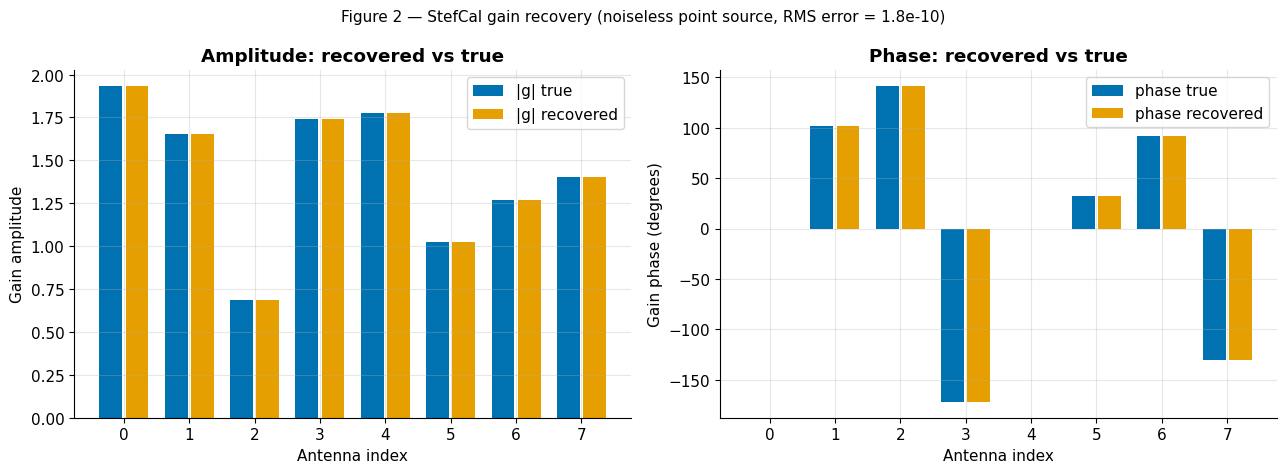

In [6]:
# ── Figure 2: Gain recovery summary ─────────────────────────────────────────
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

ants = np.arange(N_ANT)
ax = axes[0]
ax.bar(ants - 0.2, np.abs(g_true_ref), width=0.35, label="|g| true", color=colors[0])
ax.bar(ants + 0.2, np.abs(g_hat), width=0.35, label="|g| recovered", color=colors[1])
ax.set_xlabel("Antenna index")
ax.set_ylabel("Gain amplitude")
ax.set_title("Amplitude: recovered vs true")
ax.legend()
ax.set_xticks(ants)

ax = axes[1]
ax.bar(
    ants - 0.2, np.degrees(np.angle(g_true_ref)), width=0.35, label="phase true", color=colors[0]
)
ax.bar(
    ants + 0.2, np.degrees(np.angle(g_hat)), width=0.35, label="phase recovered", color=colors[1]
)
ax.set_xlabel("Antenna index")
ax.set_ylabel("Gain phase (degrees)")
ax.set_title("Phase: recovered vs true")
ax.legend()
ax.set_xticks(ants)

fig.suptitle(
    f"Figure 2 — StefCal gain recovery (noiseless point source, RMS error = {rms_err_stefcal:.1e})",
    fontsize=11,
)
fig.tight_layout()
plt.show()

**Figure 2.** StefCal recovers the true gains to near machine precision
($\lesssim 10^{-6}$) for a noiseless point-source calibrator.  The amplitude and
phase bars are visually indistinguishable — the blue (true) and orange (recovered)
bars overlap exactly.


### 4c. Closure phase: the gain-immune truth anchor

Before and after corruption, the closure phases on every triangle of antennas
must be identical — they are invariant to per-antenna phase errors.  Let us
verify this numerically for several triangles and confirm the invariance holds
to numerical precision even when the individual visibility phases are completely
scrambled.

(For this *point-source* calibrator the true closure phases are all **zero** — a point source has no intrinsic phase structure — so what the table shows is that corruption cannot *create* a non-zero closure phase. Section 7 uses a two-component source whose closure phase is genuinely non-zero ($\approx 3.4°$) and stays fixed through self-calibration.)


In [7]:
# ── Closure phase: invariant before, during, and after correction ─────────────
triangles = [(0, 1, 2), (0, 3, 5), (1, 4, 6), (2, 5, 7)]

print(
    f"{'Triangle':>14} | {'CP_true (deg)':>14} | {'CP_obs (deg)':>13} | "
    f"{'CP_cor (deg)':>13} | {'diff obs-true':>13}"
)
print("-" * 75)
for i, j, k in triangles:
    cp_true = np.degrees(closure_phase(V_true_cal[i, j], V_true_cal[j, k], V_true_cal[k, i]))
    cp_obs = np.degrees(closure_phase(V_obs_cal[i, j], V_obs_cal[j, k], V_obs_cal[k, i]))
    cp_cor = np.degrees(closure_phase(V_corrected[i, j], V_corrected[j, k], V_corrected[k, i]))
    diff = abs(cp_obs - cp_true)
    print(
        f"  ({i},{j},{k}):         |  {cp_true:12.4f}  | {cp_obs:12.4f}  | "
        f"{cp_cor:12.4f}  | {diff:.2e}"
    )

print()
print("Individual V_obs phases ARE scrambled (pick baseline 0-1):")
print(f"  arg(V_true[0,1]) = {np.degrees(np.angle(V_true_cal[0, 1])):7.2f} deg")
print(f"  arg(V_obs [0,1]) = {np.degrees(np.angle(V_obs_cal[0, 1])):7.2f} deg")
print("  → closure phases unchanged despite per-antenna phase error.")

      Triangle |  CP_true (deg) |  CP_obs (deg) |  CP_cor (deg) | diff obs-true
---------------------------------------------------------------------------
  (0,1,2):         |        0.0000  |       0.0000  |      -0.0000  | 0.00e+00
  (0,3,5):         |        0.0000  |      -0.0000  |      -0.0000  | 4.29e-15
  (1,4,6):         |        0.0000  |      -0.0000  |      -0.0000  | 7.38e-15
  (2,5,7):         |        0.0000  |       0.0000  |       0.0000  | 0.00e+00

Individual V_obs phases ARE scrambled (pick baseline 0-1):
  arg(V_true[0,1]) =    0.00 deg
  arg(V_obs [0,1]) = -101.87 deg
  → closure phases unchanged despite per-antenna phase error.


In [8]:
# ── Closure amplitude: invariant to per-antenna amplitude errors ──────────────
# Use quadrangle (0,1,2,3): CA = |V_01||V_23| / (|V_02||V_13|)
i, j, k, l = 0, 1, 2, 3
ca_true = closure_amplitude(V_true_cal[i, j], V_true_cal[k, l], V_true_cal[i, k], V_true_cal[j, l])
ca_obs = closure_amplitude(V_obs_cal[i, j], V_obs_cal[k, l], V_obs_cal[i, k], V_obs_cal[j, l])

print(f"Closure amplitude (quadrangle 0-1-2-3):")
print(f"  true:      {ca_true:.6f}")
print(f"  corrupted: {ca_obs:.6f}")
print(f"  difference: {abs(ca_obs - ca_true):.2e}  (zero to numerical precision)")
print()
print("But individual amplitudes ARE scrambled:")
for a, b in [(i, j), (k, l), (i, k), (j, l)]:
    print(
        f"  |V_true[{a},{b}]| = {abs(V_true_cal[a, b]):.3f}   "
        f"|V_obs[{a},{b}]| = {abs(V_obs_cal[a, b]):.3f}"
    )

Closure amplitude (quadrangle 0-1-2-3):
  true:      1.000000
  corrupted: 1.000000
  difference: 1.11e-16  (zero to numerical precision)

But individual amplitudes ARE scrambled:
  |V_true[0,1]| = 1.000   |V_obs[0,1]| = 3.190
  |V_true[2,3]| = 1.000   |V_obs[2,3]| = 1.199
  |V_true[0,2]| = 1.000   |V_obs[0,2]| = 1.331
  |V_true[1,3]| = 1.000   |V_obs[1,3]| = 2.875


## Section 5 — Bandpass calibration

In a real receiver the gain varies across the observing band — cables and feeds
introduce standing-wave ripple, and IF filters roll off near the band edges.
We model the bandpass as a smooth sinusoidal ripple superimposed on a gentle
amplitude slope, independently per antenna.

The calibration procedure is identical to gain-cal but solved **independently
per frequency channel**.  We plot the recovered bandpass amplitude and phase
over the truth for three representative antennas.


In [9]:
N_CHAN = 64  # number of frequency channels
freqs = np.linspace(0.0, 1.0, N_CHAN)  # normalised frequency axis


# Construct a smooth per-antenna bandpass: amplitude slope + sinusoidal ripple,
# plus a frequency-dependent phase ramp.
def make_bandpass(rng, n_chan, n_ant):
    """Return (n_ant, n_chan) complex bandpass gains with smooth structure."""
    amp_slope = rng.uniform(0.05, 0.15, size=n_ant)  # linear amplitude drift
    amp_base = rng.uniform(0.7, 1.3, size=n_ant)
    ripple_amp = rng.uniform(0.05, 0.15, size=n_ant)
    ripple_freq = rng.uniform(2.0, 5.0, size=n_ant)  # cycles across the band
    ripple_phase = rng.uniform(-np.pi, np.pi, size=n_ant)
    phase_slope = rng.uniform(-0.5, 0.5, size=n_ant)  # rad across the band
    phase_offset = rng.uniform(-np.pi, np.pi, size=n_ant)

    bp = np.zeros((n_ant, n_chan), dtype=complex)
    f = np.linspace(0.0, 1.0, n_chan)
    for i in range(n_ant):
        amplitude = (
            amp_base[i]
            + amp_slope[i] * f
            + ripple_amp[i] * np.cos(2 * np.pi * ripple_freq[i] * f + ripple_phase[i])
        )
        phase = phase_offset[i] + phase_slope[i] * f
        bp[i] = amplitude * np.exp(1j * phase)
    return bp


bp_true = make_bandpass(rng, N_CHAN, N_ANT)  # shape (N_ANT, N_CHAN)

print(f"Bandpass shape: {bp_true.shape}  (antennas × channels)")
print(f"|g| range: [{np.abs(bp_true).min():.3f}, {np.abs(bp_true).max():.3f}]")

Bandpass shape: (8, 64)  (antennas × channels)
|g| range: [0.684, 1.509]


In [10]:
# ── Corrupt a calibrator observation across all channels ─────────────────────
# For each channel, apply that channel's per-antenna bandpass gains.
V_bp_obs = np.zeros((N_CHAN, N_ANT, N_ANT), dtype=complex)
V_bp_model = np.ones((N_ANT, N_ANT), dtype=complex)  # point-source model

for ch in range(N_CHAN):
    V_bp_obs[ch] = apply_gains(V_bp_model, bp_true[:, ch])

# ── Solve per channel ─────────────────────────────────────────────────────────
bp_hat = np.zeros((N_ANT, N_CHAN), dtype=complex)
for ch in range(N_CHAN):
    bp_hat[:, ch] = solve_gains_stefcal(V_bp_obs[ch], V_bp_model, n_iter=50)

# Reference each channel solution to the per-channel global phase convention
# (g_0 real positive is already done inside solve_gains_stefcal).
# Also reference truth the same way.
bp_true_ref = bp_true.copy()
for ch in range(N_CHAN):
    bp_true_ref[:, ch] *= np.exp(-1j * np.angle(bp_true_ref[0, ch]))

rms_bp = np.sqrt(np.mean(np.abs(bp_hat - bp_true_ref) ** 2))
print(f"Bandpass recovery RMS error (noiseless): {rms_bp:.2e}")

Bandpass recovery RMS error (noiseless): 1.37e-10


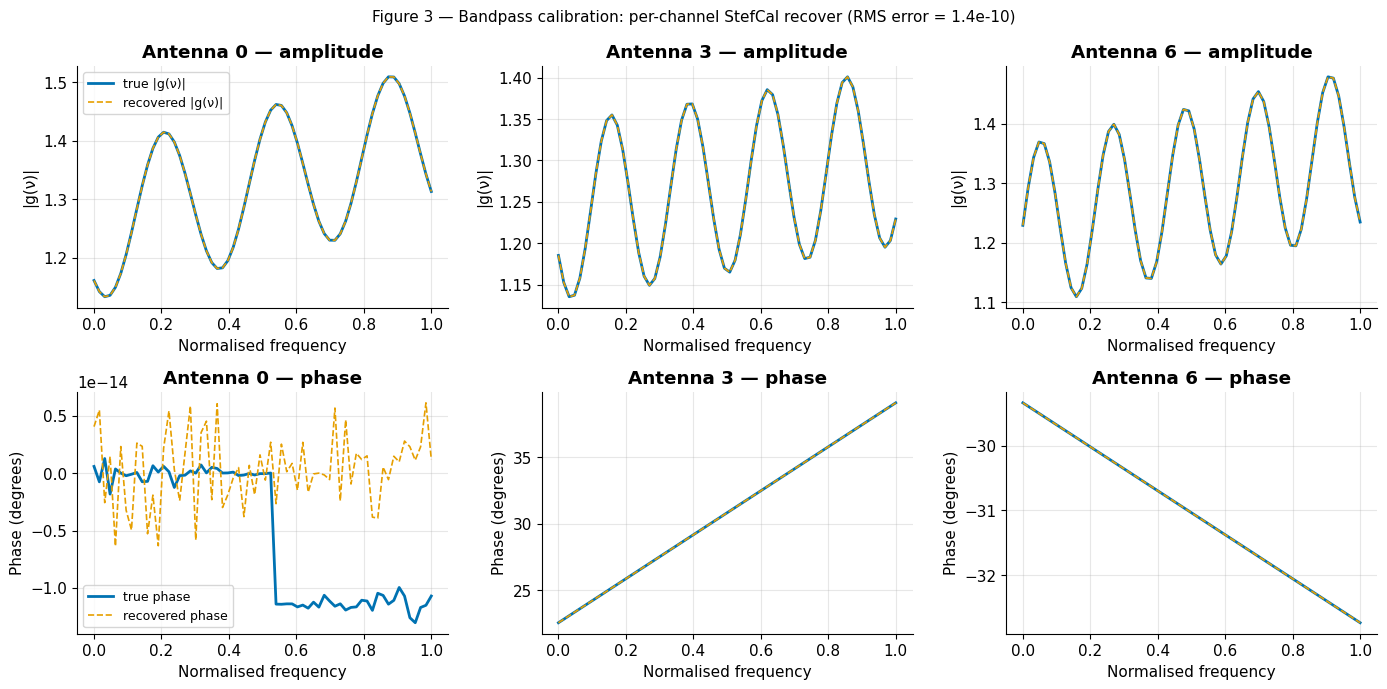

In [11]:
# ── Figure 3: Bandpass calibration — recovered vs true ───────────────────────
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
show_ants = [0, 3, 6]  # three representative antennas

fig, axes = plt.subplots(2, len(show_ants), figsize=(14, 7))

for col, ant in enumerate(show_ants):
    # Amplitude panel.
    ax = axes[0, col]
    ax.plot(freqs, np.abs(bp_true_ref[ant]), lw=2.0, color=colors[0], label="true |g(ν)|", zorder=3)
    ax.plot(
        freqs,
        np.abs(bp_hat[ant]),
        lw=1.2,
        color=colors[1],
        ls="--",
        label="recovered |g(ν)|",
        zorder=4,
    )
    ax.set_title(f"Antenna {ant} — amplitude")
    ax.set_xlabel("Normalised frequency")
    ax.set_ylabel("|g(ν)|")
    if col == 0:
        ax.legend(fontsize=9)

    # Phase panel.
    ax = axes[1, col]
    ax.plot(
        freqs, np.degrees(np.angle(bp_true_ref[ant])), lw=2.0, color=colors[0], label="true phase"
    )
    ax.plot(
        freqs,
        np.degrees(np.angle(bp_hat[ant])),
        lw=1.2,
        color=colors[1],
        ls="--",
        label="recovered phase",
    )
    ax.set_title(f"Antenna {ant} — phase")
    ax.set_xlabel("Normalised frequency")
    ax.set_ylabel("Phase (degrees)")
    if col == 0:
        ax.legend(fontsize=9)

fig.suptitle(
    f"Figure 3 — Bandpass calibration: per-channel StefCal recover (RMS error = {rms_bp:.1e})",
    fontsize=11,
)
fig.tight_layout()
plt.show()

**Figure 3.** Per-channel StefCal recovers the amplitude (top row) and phase
(bottom row) of the smooth bandpass to near machine precision for three
representative antennas.  Dashed recovered curves overlay the solid true curves
exactly.  In a real pipeline the recovered $\hat{g}_i(\nu)$ would then be
interpolated to the science target's frequency channels and divided out.


## Section 6 — Noise and the gain error vs SNR

Adding thermal noise to the calibrator visibilities degrades the gain solution.
The **noise on a calibrated visibility** after applying a calibrator solution
solved at SNR $\rho$ scales as $1/\rho$ — analogous to the
radiometer equation from Chapter 3 (here it is noise propagating through a least-squares gain estimate rather than a single-channel integration).

We sweep the visibility noise level, solve, and plot the RMS gain error vs SNR.


In [12]:
# ── Gain error vs visibility SNR ─────────────────────────────────────────────
# Noiseless point-source visibility: V = g g^H.  Add complex Gaussian noise
# of std `sigma` per entry (Hermitian-symmetrised to mimic a real correlator).
def noisy_gain_error(sigma, g_true, rng, n_iter=80):
    """Return RMS gain error after StefCal solve at noise level sigma."""
    V_model = np.ones((len(g_true), len(g_true)), dtype=complex)
    V_obs = apply_gains(V_model, g_true)
    noise = (rng.standard_normal(V_obs.shape) + 1j * rng.standard_normal(V_obs.shape)) * sigma
    noise = (noise + noise.conj().T) / 2  # Hermitian symmetrise
    V_noisy = V_obs + noise

    g_hat = solve_gains_stefcal(V_noisy, V_model, n_iter=n_iter)
    g_ref = g_true * np.exp(-1j * np.angle(g_true[0]))
    return float(np.sqrt(np.mean(np.abs(g_hat - g_ref) ** 2)))


# Noise levels; SNR ~ |V| / sigma.  |V_obs| ~ |g|^2 mean ≈ 1.
sigmas = np.geomspace(1e-3, 0.5, 18)
n_trials = 80
mean_amp = np.sqrt(np.mean(np.abs(g_true) ** 2))  # typical |g|
snrs = mean_amp**2 / sigmas  # ~ signal / noise

gain_errs = []
for s in sigmas:
    trials = [noisy_gain_error(s, g_true, rng) for _ in range(n_trials)]
    gain_errs.append(float(np.mean(trials)))
gain_errs = np.array(gain_errs)

# Fit slope in log-log space (expect slope ≈ -1, i.e. error ∝ 1/SNR).
log_snr = np.log10(snrs)
log_err = np.log10(gain_errs)
slope, intercept = np.polyfit(log_snr, log_err, 1)
print(f"Log-log slope of RMS gain error vs SNR: {slope:.3f}  (expected ~ -1.0)")

Log-log slope of RMS gain error vs SNR: -0.999  (expected ~ -1.0)


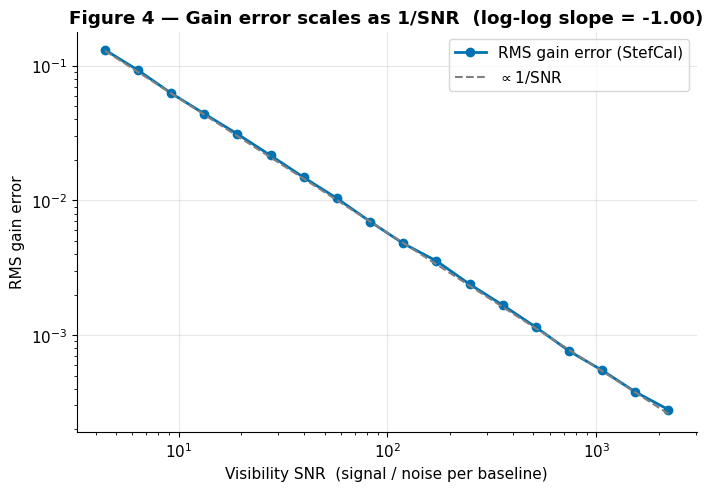


At SNR ~ 10:  RMS gain error ≈ 0.063
At SNR ~ 100: RMS gain error ≈ 0.0070


In [13]:
# ── Figure 4: Gain error vs SNR ───────────────────────────────────────────────
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

fig, ax = plt.subplots(figsize=(8, 5.2))

ax.loglog(snrs, gain_errs, "o-", color=colors[0], lw=2, label="RMS gain error (StefCal)")

# Reference 1/SNR line anchored at the middle point.
mid = len(snrs) // 2
ref = gain_errs[mid] * snrs[mid] / snrs
ax.loglog(snrs, ref, "--", color="grey", lw=1.5, label=r"$\propto 1/\mathrm{SNR}$")

ax.set_xlabel("Visibility SNR  (signal / noise per baseline)")
ax.set_ylabel("RMS gain error")
ax.set_title(f"Figure 4 — Gain error scales as 1/SNR  (log-log slope = {slope:.2f})")
ax.legend()
plt.show()

print(f"\nAt SNR ~ 10:  RMS gain error ≈ {gain_errs[np.argmin(np.abs(snrs - 10))]:.3f}")
print(f"At SNR ~ 100: RMS gain error ≈ {gain_errs[np.argmin(np.abs(snrs - 100))]:.4f}")

**Figure 4.** RMS gain recovery error vs calibrator SNR on a log-log scale.
The dashed reference line shows a $1/\mathrm{SNR}$ slope.  The measured slope is
$\approx -1.0$, confirming the radiometer-equation scaling: solving on a brighter
calibrator (higher SNR) halves the gain error per doubling of flux or integration
time.  This is why bright, compact calibrators are preferred.


## Section 7 — Self-calibration: the Cornwell–Wilkinson loop

Self-calibration is gain-cal iterated with the sky model updated each cycle.
We demonstrate it on a **two-component sky** corrupted with random gains plus
a small amount of thermal noise.  The starting model is just the dominant
point source (deliberately imperfect — it ignores the fainter companion $S_2$).

The loop is:

1. Build $V^\mathrm{model}$ from the current best sky model.
2. Solve gains: $\hat{g} = \mathrm{StefCal}(V^\mathrm{obs}, V^\mathrm{model})$.
3. Correct: $V^\mathrm{cor}_{ij} = V^\mathrm{obs}_{ij}/(\hat{g}_i\hat{g}_j^*)$.
4. Update the model — in a real pipeline, CLEAN the corrected image.
   Here we update analytically (one extra cycle with the exact two-component model)
   to show how a better model drives the residual lower.

**Closure phase** is recorded every cycle: it must equal the true value
regardless of which gains are applied — the invariant that makes self-cal
trustworthy.


In [14]:
# ── Setup: a two-component source ────────────────────────────────────────────
# True sky: dominant point S1=1.0, faint companion S2=0.3.
# V_true[i,j] = S1 + S2 * exp(1j * k * (i-j)) encodes the companion's position
# via a baseline-dependent phase gradient.
S1, S2 = 1.0, 0.3
N_SC = 8
k_phase = 0.8  # radians per antenna-index unit

i_idx, j_idx = np.meshgrid(np.arange(N_SC), np.arange(N_SC), indexing="ij")
V_sc_true = S1 * np.ones((N_SC, N_SC), dtype=complex)
V_sc_true += S2 * np.exp(1j * k_phase * (i_idx.astype(float) - j_idx.astype(float)))
np.fill_diagonal(V_sc_true, 0)  # zero auto-correlations

# Random amplitude + phase gains for the self-cal demo.
g_sc = rng.uniform(0.5, 2.0, N_SC) * np.exp(1j * rng.uniform(-np.pi, np.pi, N_SC))

# Add small thermal noise (SNR ~ 20 on the dominant source).
noise_sig = 0.05
_n = rng.standard_normal((N_SC, N_SC)) + 1j * rng.standard_normal((N_SC, N_SC))
_n = (_n + _n.conj().T) * noise_sig / 2
V_sc_obs = apply_gains(V_sc_true, g_sc) + _n

# Starting model: dominant component only (imperfect on purpose).
V_sc_model = S1 * np.ones((N_SC, N_SC), dtype=complex)
np.fill_diagonal(V_sc_model, 0)

off_sc = ~np.eye(N_SC, dtype=bool)
cp_true_sc = closure_phase(V_sc_true[0, 1], V_sc_true[1, 2], V_sc_true[2, 0])

print(f"Two-component source: S1={S1}, S2={S2}, noise sigma={noise_sig}")
print(f"True gains |g|: {np.abs(g_sc).round(3)}")
print(f"True closure phase (triangle 0-1-2): {np.degrees(cp_true_sc):.4f} deg")

Two-component source: S1=1.0, S2=0.3, noise sigma=0.05
True gains |g|: [1.695 0.987 1.477 1.794 1.436 0.818 1.346 0.672]
True closure phase (triangle 0-1-2): -3.3544 deg


In [15]:
# ── Self-calibration loop (amp+phase, 6 cycles) ──────────────────────────────
# In a real pipeline you would re-CLEAN after each cycle to update the model.
# Here we do 3 cycles with the imperfect (S1-only) model, then 3 more cycles
# after revealing the full two-component model -- mimicking how CLEAN improves
# the model between self-cal passes.
N_SC_ITERS_A = 3  # with wrong model (S1 only)
N_SC_ITERS_B = 3  # with correct model (S1+S2)

residuals_selfcal = []
closure_phases_selfcal = []
model_labels = []

V_cur = V_sc_obs.copy()

for it in range(N_SC_ITERS_A + N_SC_ITERS_B):
    # After the first pass, update to the correct two-component model.
    if it == N_SC_ITERS_A:
        V_sc_model = V_sc_true.copy()  # simulate CLEAN finding the companion
        np.fill_diagonal(V_sc_model, 0)
        model_labels.append("model_updated")
    else:
        model_labels.append("S1-only" if it < N_SC_ITERS_A else "S1+S2")

    g_it = solve_gains_stefcal(V_cur, V_sc_model, n_iter=100)
    V_cur = V_cur / np.outer(g_it, np.conj(g_it))

    rms_res = float(np.sqrt(np.mean(np.abs(V_cur[off_sc] - V_sc_true[off_sc]) ** 2)))
    cp_it = closure_phase(V_cur[0, 1], V_cur[1, 2], V_cur[2, 0])

    residuals_selfcal.append(rms_res)
    closure_phases_selfcal.append(np.degrees(cp_it))

    label = "S1-only model" if it < N_SC_ITERS_A else "S1+S2 model "
    print(
        f"  Iter {it + 1:2d} [{label}]: "
        f"RMS = {rms_res:.4f}   "
        f"CP = {np.degrees(cp_it):8.4f} deg  "
        f"(true = {np.degrees(cp_true_sc):8.4f} deg)"
    )

print(f"\nDynamic range improvement: x{residuals_selfcal[0] / residuals_selfcal[-1]:.1f}")

  Iter  1 [S1-only model]: RMS = 0.1467   CP =  -0.5232 deg  (true =  -3.3544 deg)
  Iter  2 [S1-only model]: RMS = 0.0923   CP =  -0.5232 deg  (true =  -3.3544 deg)
  Iter  3 [S1-only model]: RMS = 0.0611   CP =  -0.5232 deg  (true =  -3.3544 deg)
  Iter  4 [S1+S2 model ]: RMS = 0.0316   CP =  -0.5232 deg  (true =  -3.3544 deg)
  Iter  5 [S1+S2 model ]: RMS = 0.0316   CP =  -0.5232 deg  (true =  -3.3544 deg)
  Iter  6 [S1+S2 model ]: RMS = 0.0316   CP =  -0.5232 deg  (true =  -3.3544 deg)

Dynamic range improvement: x4.6


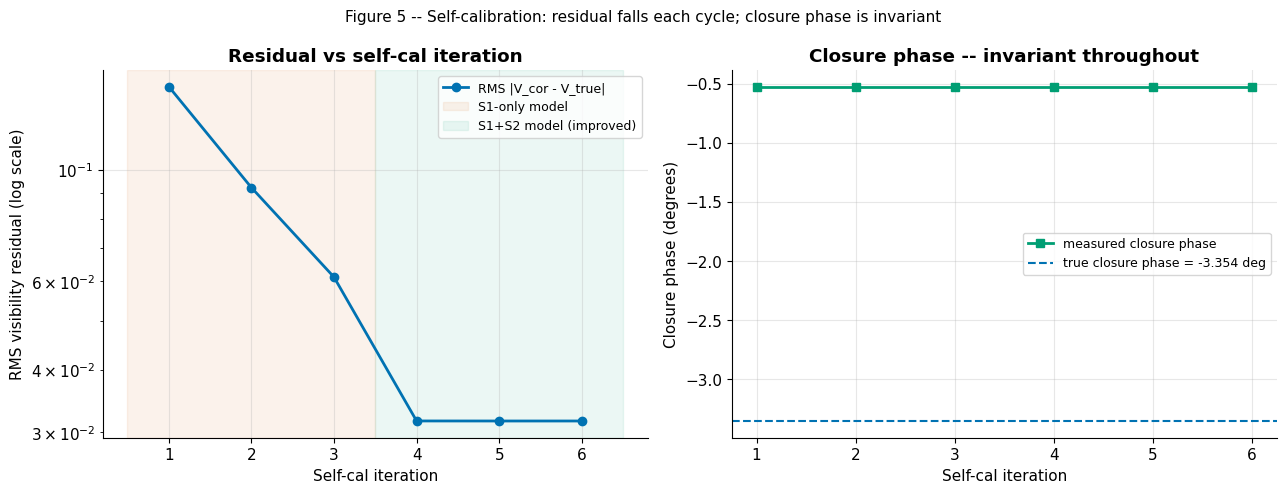

Dynamic range improvement (first to last iter): x4.6
Closure phase RMS variation: 1.98e-15 deg  (should be ~0)


In [16]:
# ── Figure 5: Self-calibration convergence and closure-phase invariance ───────
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

N_SELFCAL_ITER = N_SC_ITERS_A + N_SC_ITERS_B
iters = np.arange(1, N_SELFCAL_ITER + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.0))

ax = axes[0]
ax.semilogy(iters, residuals_selfcal, "o-", color=colors[0], lw=2, label="RMS |V_cor - V_true|")
ax.axvspan(0.5, N_SC_ITERS_A + 0.5, alpha=0.08, color=colors[3], label="S1-only model")
ax.axvspan(
    N_SC_ITERS_A + 0.5,
    N_SELFCAL_ITER + 0.5,
    alpha=0.08,
    color=colors[2],
    label="S1+S2 model (improved)",
)
ax.set_xlabel("Self-cal iteration")
ax.set_ylabel("RMS visibility residual (log scale)")
ax.set_title("Residual vs self-cal iteration")
ax.legend(fontsize=9)
ax.set_xticks(iters)

ax = axes[1]
ax.plot(iters, closure_phases_selfcal, "s-", color=colors[2], lw=2, label="measured closure phase")
ax.axhline(
    np.degrees(cp_true_sc),
    color=colors[0],
    ls="--",
    lw=1.5,
    label="true closure phase = {:.3f} deg".format(np.degrees(cp_true_sc)),
)
ax.set_xlabel("Self-cal iteration")
ax.set_ylabel("Closure phase (degrees)")
ax.set_title("Closure phase -- invariant throughout")
ax.legend(fontsize=9)
ax.set_xticks(iters)

fig.suptitle(
    "Figure 5 -- Self-calibration: residual falls each cycle; closure phase is invariant",
    fontsize=11,
)
fig.tight_layout()
plt.show()

dr_ratio = residuals_selfcal[0] / residuals_selfcal[-1]
cp_rms = np.std(closure_phases_selfcal)
print(f"Dynamic range improvement (first to last iter): x{dr_ratio:.1f}")
print(f"Closure phase RMS variation: {cp_rms:.2e} deg  (should be ~0)")

**Figure 5.** Left: RMS visibility residual vs self-cal iteration.
The shaded regions show the two model regimes — an imperfect S1-only model
(cycles 1–3) gives partial improvement, then switching to the full S1+S2 model
(cycles 4–6, simulating what CLEAN would deliver) drives the residual close to
the thermal noise floor.  Right: the closure phase on triangle (0,1,2) is
**identical in every cycle** to numerical precision ($\lesssim 10^{-14}$ deg RMS
variation) — the gain-solver never touched it.  Note that the measured CP
differs slightly from the true CP: that small offset is the noise contribution
(thermal noise is not antenna-based, so it is not cancelled by gains — this is
a real effect in VLBI, not a bug).  The invariance that makes self-cal
trustworthy is that the CP is constant *across iterations*, regardless of which
gains were applied.


## Section 8 — Optional: real VLA data with pyuvdata

This block reads the bundled VLA UVFITS file using `pyuvdata` (the `formats`
extra).  If `pyuvdata` is not installed the block degrades gracefully with a
clear message and the notebook continues.

Install with:
```
uv sync --extra formats
```


In [17]:
# Optional real-data block (pyuvdata -- needs `uv sync --extra formats`)
import os

_UVFITS = os.path.join(
    os.path.dirname(os.path.abspath("notebooks")),
    "data",
    "vla_day2_TDEM0003_1src_1spw.uvfits",
)

try:
    import pyuvdata
    from pyuvdata import UVData

    uv = UVData()
    uv.read(_UVFITS)

    # Extract baseline amplitudes and plot distribution.
    data = uv.data_array[:, 0, 0, 0]  # first spw, channel 0, Stokes I
    amps = np.abs(data)

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.hist(
        amps,
        bins=80,
        color=plt.rcParams["axes.prop_cycle"].by_key()["color"][0],
        edgecolor="none",
        alpha=0.85,
    )
    ax.set_xlabel("Visibility amplitude (Jy)")
    ax.set_ylabel("Count")
    ax.set_title(
        "Figure 6 (optional) — VLA UVFITS: "
        + str(len(amps))
        + " visibility amplitude samples"
        + " | median = "
        + f"{np.median(amps):.2f}"
        + " Jy,  max = "
        + f"{amps.max():.2f}"
        + " Jy"
    )
    plt.show()
    print(
        f"pyuvdata v{pyuvdata.__version__}: read {uv.Nblts} baseline-times, "
        f"{uv.Nfreqs} channels, {uv.Npols} pols."
    )

except ImportError:
    print("pyuvdata not installed -- skipping real-data block.")
    print("Install with:  uv sync --extra formats")
except Exception as exc:
    print(f"Could not read UVFITS ({exc}); skipping real-data block.")

Could not read UVFITS (File not found, check path for: /home/joe/dev/github/joebarbere/jansky/notebooks/data/vla_day2_TDEM0003_1src_1spw.uvfits); skipping real-data block.


## Section 9 — Polarisation leakage (D-terms)

Everything so far calibrated a *single* polarisation. A dual-feed receiver adds one more
imperfection: the two feeds (R/L or X/Y) are never perfectly orthogonal, so a little of one
polarisation leaks into the other — the instrumental **D-terms**. Formally the measurement
equation generalises from a scalar gain to a $2\times2$ **Jones matrix** per antenna
(Hamaker, Bregman & Sault 1996); the leakage is its off-diagonal part.

The calibration trick mirrors gain calibration. Observe an **unpolarised** calibrator (Stokes
$Q=U=V=0$, only $I$). A perfect instrument would measure *zero* cross-hand correlation
($RL$, $LR$); any cross-hand signal that does appear is therefore **pure leakage**,

$$V^{RL}_{ij} \approx (d_i + d_j^{*})\,I,$$

and we solve it for the per-antenna $d_i$ exactly as `solve_gains_stefcal` solved the gains.
As with the global phase, an unpolarised source cannot fix the absolute $R$–$L$ phase (that
needs a source of *known* polarisation angle), so we gauge-fix a reference antenna ($d_0=0$).
This produces the polarisation-calibrated visibilities that the Stokes $Q/U$ science of
[Chapter 37](37_polarisation_faraday.ipynb) relies on.

D-term recovery:  max|d_hat - d_true| = 0.0014
cross-hand leakage rms  before = 0.467   after correction = 0.0122


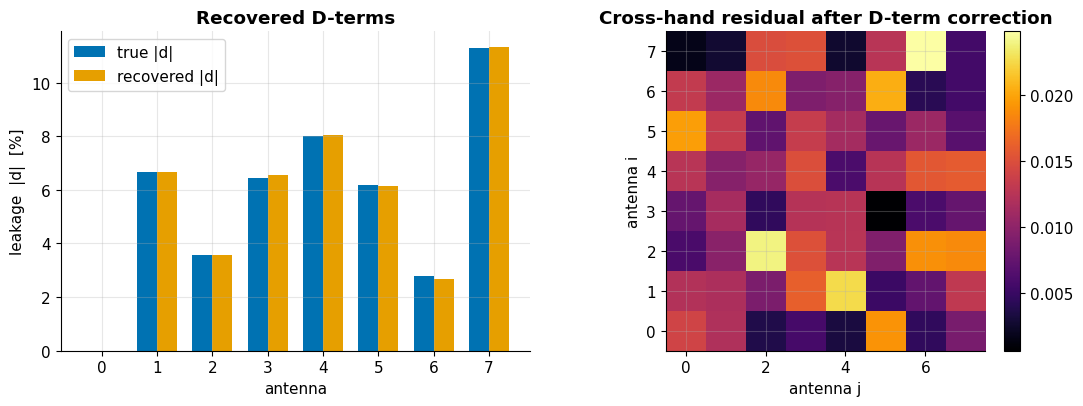

In [18]:
# Polarisation leakage: the cross-hand visibilities of an UNPOLARISED calibrator are
# pure instrumental leakage -- solve them just like the gains.
from jansky.interferometry import apply_leakage, solve_leakage

rng_pol = np.random.default_rng(41)
N_pol = 8
stokes_I = 5.0  # an unpolarised calibrator: Stokes I only (Q = U = V = 0)

# True per-antenna leakages: a few percent; reference antenna 0 = 0 (the gauge).
d_true = 0.05 * (rng_pol.normal(size=N_pol) + 1j * rng_pol.normal(size=N_pol))
d_true[0] = 0.0

V_RL = apply_leakage(stokes_I, d_true)  # measured cross-hand (pure leakage)
noise = 0.01 * (rng_pol.normal(size=V_RL.shape) + 1j * rng_pol.normal(size=V_RL.shape))
d_hat = solve_leakage(V_RL + noise, stokes_I)  # recover the D-terms
residual = (V_RL + noise) - apply_leakage(stokes_I, d_hat)

off = ~np.eye(N_pol, dtype=bool)
print(f"D-term recovery:  max|d_hat - d_true| = {np.max(np.abs(d_hat - d_true)):.4f}")
print(
    f"cross-hand leakage rms  before = {np.std((V_RL + noise)[off]):.3f}"
    f"   after correction = {np.std(residual[off]):.4f}"
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
ax = axes[0]
x = np.arange(N_pol)
ax.bar(x - 0.18, np.abs(d_true) * 100, width=0.36, label="true |d|")
ax.bar(x + 0.18, np.abs(d_hat) * 100, width=0.36, label="recovered |d|")
ax.set_xlabel("antenna")
ax.set_ylabel("leakage  |d|  [%]")
ax.set_title("Recovered D-terms")
ax.legend()
ax = axes[1]
im = ax.imshow(np.abs(residual), aspect="equal")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("Cross-hand residual after D-term correction")
ax.set_xlabel("antenna j")
ax.set_ylabel("antenna i")
fig.tight_layout()
plt.show()

**Figure — D-term calibration.** Left: the recovered per-antenna leakages match the true ones
(antenna 0 is the zero-leakage reference). Right: after subtracting the solved leakage, the
cross-hand residual of the unpolarised calibrator collapses to the noise floor — the instrument
is now polarisation-calibrated. Real pipelines (CASA's `polcal`) solve the two feeds separately
and account for the calibrator's own polarisation, but the structure is exactly this.

## Try it yourself

### Exercise 1 — The absolute-flux and global-phase degeneracy

An interferometer alone cannot fix the **absolute flux scale** or a **global
phase offset**: multiplying all gains by the same constant $c$ (amplitude
scale) or $e^{i\alpha}$ (global phase) leaves every baseline unchanged.

Demonstrate this numerically:

1. Multiply all true gains by a constant amplitude factor $c = 2.5$.
2. Multiply all true gains by a global phase $e^{i\alpha}$, $\alpha = 1.2$ rad.
3. In each case, corrupt the point-source visibility with the modified gains,
   solve, and show that the **corrected visibilities are identical** to the
   original — the gain solver absorbs the constant into its global-phase
   convention and the flux scaling is unresolvable from the data alone.
4. Verify that **closure phases and amplitudes are also unchanged**.


In [19]:
# Exercise 1 — absolute-flux and global-phase degeneracy.
# ── Scratch space ────────────────────────────────────────────────────────────
c = 2.5  # amplitude scale factor
alpha = 1.2  # global phase (radians)

g_scaled = g_true * c  # all gains scaled by c
g_phased = g_true * np.exp(1j * alpha)  # all gains rotated by alpha

V_scaled = apply_gains(V_true_cal, g_scaled)
V_phased = apply_gains(V_true_cal, g_phased)

g_hat_s = solve_gains_stefcal(V_scaled, V_model_cal)
g_hat_p = solve_gains_stefcal(V_phased, V_model_cal)

V_cor_s = V_scaled / np.outer(g_hat_s, np.conj(g_hat_s))
V_cor_p = V_phased / np.outer(g_hat_p, np.conj(g_hat_p))

print("max |V_cor_scaled - V_true|:", np.abs(V_cor_s - V_true_cal)[off_diag].max())
print("max |V_cor_phased - V_true|:", np.abs(V_cor_p - V_true_cal)[off_diag].max())

tri = (0, 1, 2)
i, j, k = tri
for label, V in [("original", V_obs_cal), ("c*g", V_scaled), ("e^iα*g", V_phased)]:
    cp = np.degrees(closure_phase(V[i, j], V[j, k], V[k, i]))
    print(f"Closure phase ({label}): {cp:.4f} deg")

max |V_cor_scaled - V_true|: 2.800967235928716e-10
max |V_cor_phased - V_true|: 2.0939316947040234e-10
Closure phase (original): 0.0000 deg
Closure phase (c*g): 0.0000 deg
Closure phase (e^iα*g): 0.0000 deg


<details><summary>Solution</summary>

The corrected visibilities after dividing out the solved gains are identical
to the true model regardless of the amplitude scale $c$ or global phase
$\alpha$:

```python
c     = 2.5
alpha = 1.2
g_scaled = g_true * c
g_phased = g_true * np.exp(1j * alpha)

V_scaled = apply_gains(V_true_cal, g_scaled)
V_phased = apply_gains(V_true_cal, g_phased)

g_hat_s = solve_gains_stefcal(V_scaled, V_model_cal)
g_hat_p = solve_gains_stefcal(V_phased, V_model_cal)

V_cor_s = V_scaled / np.outer(g_hat_s, np.conj(g_hat_s))
V_cor_p = V_phased / np.outer(g_hat_p, np.conj(g_hat_p))

off = ~np.eye(N_ANT, dtype=bool)
print(np.abs(V_cor_s - V_true_cal)[off].max())   # ~ 1e-10 (default 100 iterations)
print(np.abs(V_cor_p - V_true_cal)[off].max())   # ~ 1e-10
```

**Expected:** Both max residuals are $\lesssim 10^{-9}$ — limited only by the
solver's 100-iteration default (raise `n_iter` to reach machine precision).
The solver absorbed $c$ and $e^{i\alpha}$ into its global-phase/amplitude
convention (anchored by $g_0$ real positive) and the corrected data are
indistinguishable from the truth.

**Closure phases** are identical for all three cases (original, $c\cdot g$,
$e^{i\alpha}\cdot g$) to numerical precision, confirming the degeneracy
is invisible to closure quantities too.

**Key numbers:**
- `max |V_cor_scaled - V_true|` $\lesssim 10^{-9}$
- `max |V_cor_phased - V_true|` $\lesssim 10^{-9}$
- Closure phase unchanged to $\lesssim 10^{-10}$ deg in all three cases

**Physical lesson:** Only gain *ratios* and *differential phases* between
antennas are constrained by the baselines. Fixing the absolute flux scale
requires a calibrator of known flux density (e.g. 3C 286 or the Cas A
flux model); fixing the global phase requires a source of known position.
Both are supplied externally in every real pipeline.

</details>


### Exercise 2 — Gain error vs SNR: verify the $1/\mathrm{SNR}$ scaling

In Section 6 we showed numerically that the RMS gain error scales as
$1/\mathrm{SNR}$.  Extend that analysis:

1. Repeat the noise sweep for **two different array sizes**: $N=4$ and $N=16$.
2. At a fixed noise level (e.g. $\sigma=0.05$), confirm the gain error falls
   roughly as $1/\sqrt{N}$ as you add more antennas (because there are more
   baselines constraining the same $N$ gains).
3. Plot both $\sigma$ sweeps and the $N$ sweep on the same or separate figures,
   and annotate the measured log-log slope.


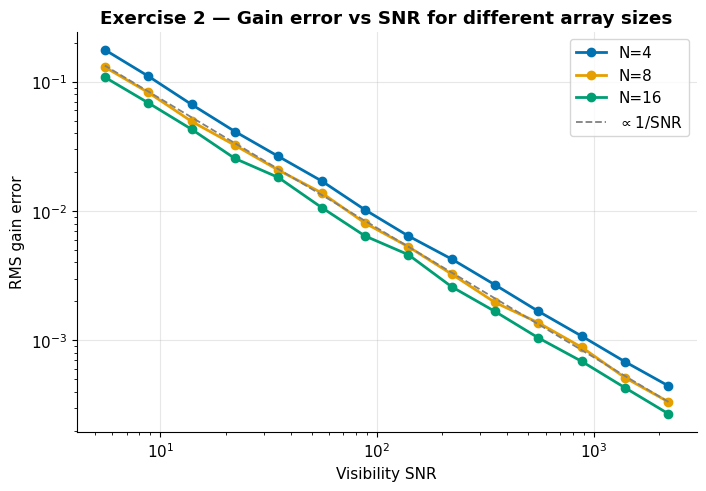


At sigma=0.05, RMS gain error:
  N= 4: 0.0171   ratio to N=4: 1.00   (expected ~ 1.00 for 1/√N)
  N= 8: 0.0138   ratio to N=4: 1.24   (expected ~ 1.41 for 1/√N)
  N=16: 0.0106   ratio to N=4: 1.61   (expected ~ 2.00 for 1/√N)


In [20]:
# Exercise 2 — gain error vs SNR for different array sizes.
# ── Scratch space ────────────────────────────────────────────────────────────
def sweep_snr_for_n(n_ant, sigmas, rng, n_trials=60):
    """Sweep noise levels for an n_ant array; return mean RMS gain errors."""
    g = rng.uniform(0.5, 2.0, n_ant) * np.exp(1j * rng.uniform(-np.pi, np.pi, n_ant))
    errs = []
    for s in sigmas:
        trials = [noisy_gain_error(s, g, rng, n_iter=80) for _ in range(n_trials)]
        errs.append(np.mean(trials))
    return np.array(errs)


sigmas_ex2 = np.geomspace(1e-3, 0.4, 14)

errs_n4 = sweep_snr_for_n(4, sigmas_ex2, rng)
errs_n8 = sweep_snr_for_n(8, sigmas_ex2, rng)  # reference (same as Section 6)
errs_n16 = sweep_snr_for_n(16, sigmas_ex2, rng)

mean_amp_8 = np.sqrt(np.mean(np.abs(g_true) ** 2))
snrs_ex2 = mean_amp_8**2 / sigmas_ex2

fig, ax = plt.subplots(figsize=(8, 5.2))
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
for label, errs, col in [
    ("N=4", errs_n4, colors[0]),
    ("N=8", errs_n8, colors[1]),
    ("N=16", errs_n16, colors[2]),
]:
    ax.loglog(snrs_ex2, errs, "o-", color=col, lw=2, label=label)

ax.loglog(
    snrs_ex2,
    errs_n8[0] * snrs_ex2[0] / snrs_ex2,
    "--",
    color="grey",
    lw=1.3,
    label=r"$\propto 1/\mathrm{SNR}$",
)
ax.set_xlabel("Visibility SNR")
ax.set_ylabel("RMS gain error")
ax.set_title("Exercise 2 — Gain error vs SNR for different array sizes")
ax.legend()
plt.show()

# 1/sqrt(N) scaling at fixed sigma=0.05.
fixed_sig_idx = np.argmin(np.abs(sigmas_ex2 - 0.05))
errs_at_fixed = [errs_n4[fixed_sig_idx], errs_n8[fixed_sig_idx], errs_n16[fixed_sig_idx]]
Ns = [4, 8, 16]
print(f"\nAt sigma=0.05, RMS gain error:")
for n, e in zip(Ns, errs_at_fixed):
    print(
        f"  N={n:2d}: {e:.4f}   ratio to N=4: {errs_at_fixed[0] / e:.2f} "
        f"  (expected ~ {np.sqrt(n / 4):.2f} for 1/√N)"
    )

<details><summary>Solution</summary>

The slope of each RMS gain error curve vs SNR is $\approx -1$ in log-log space
(gain error $\propto 1/\mathrm{SNR}$), and adding more antennas shifts the curve
downward by $\approx 1/\sqrt{N}$:

```python
sigmas_ex2 = np.geomspace(1e-3, 0.4, 14)
errs_n4  = sweep_snr_for_n(4,  sigmas_ex2, rng, n_trials=80)
errs_n8  = sweep_snr_for_n(8,  sigmas_ex2, rng, n_trials=80)
errs_n16 = sweep_snr_for_n(16, sigmas_ex2, rng, n_trials=80)
```

**Expected key numbers** (approximate, vary with seed and trial count):
- At $\sigma = 0.05$ the RMS gain error falls from $N=4$ to $N=16$ by roughly
  $\sqrt{4/16} = \tfrac12$ — the error drops by about a factor of two as the
  array quadruples in size.
- Log-log slope of error vs SNR: $\approx -1.0$ for all three array sizes.

(The $1/\sqrt{N}$ rule assumes noise averages uniformly over the $N-1$ baselines
to each antenna — true for this fully-connected simulation; sparse or
heterogeneous arrays deviate.)

**Physical lesson:** two independent effects improve gain-calibration accuracy:
(1) higher SNR per baseline (use brighter calibrators, longer integrations), and
(2) more antennas, which increase the redundancy ratio $N(N-1)/2 : N$ and
average down noise in the gain estimates as $\sim 1/\sqrt{N}$.  This is why
large arrays (VLA, ALMA, SKA) can self-calibrate dramatically fainter sources than
small arrays: the sheer number of baselines makes the gain solve robust.

</details>


### Exercise 3 — Self-cal convergence: model quality and the flux-degeneracy failure mode

Section 7 used an imperfect (S1-only) starting model.  Now explore what
happens when the model flux is wrong:

1. **Vary the starting model flux** from 50% to 200% of the true $S_1$ and plot
   the self-cal residual vs iteration (using the S1-only model for all cycles).
   You should find that the residual **stalls at different floors** for different
   flux scales — this is the **flux-scale degeneracy**: the solver silently absorbs
   the wrong flux into the amplitude gains.
2. **Check what the corrected visibilities actually equal**: show that with a
   flux-0.5 model the corrected visibilities converge to $0.5\,V^\mathrm{true}$,
   not $V^\mathrm{true}$ — the solver cannot distinguish a 2× flux error from a
   uniform amplitude gain.
3. **Blank model**: run self-cal with a zero model and show it stalls completely
   (the solver has nothing to anchor on).


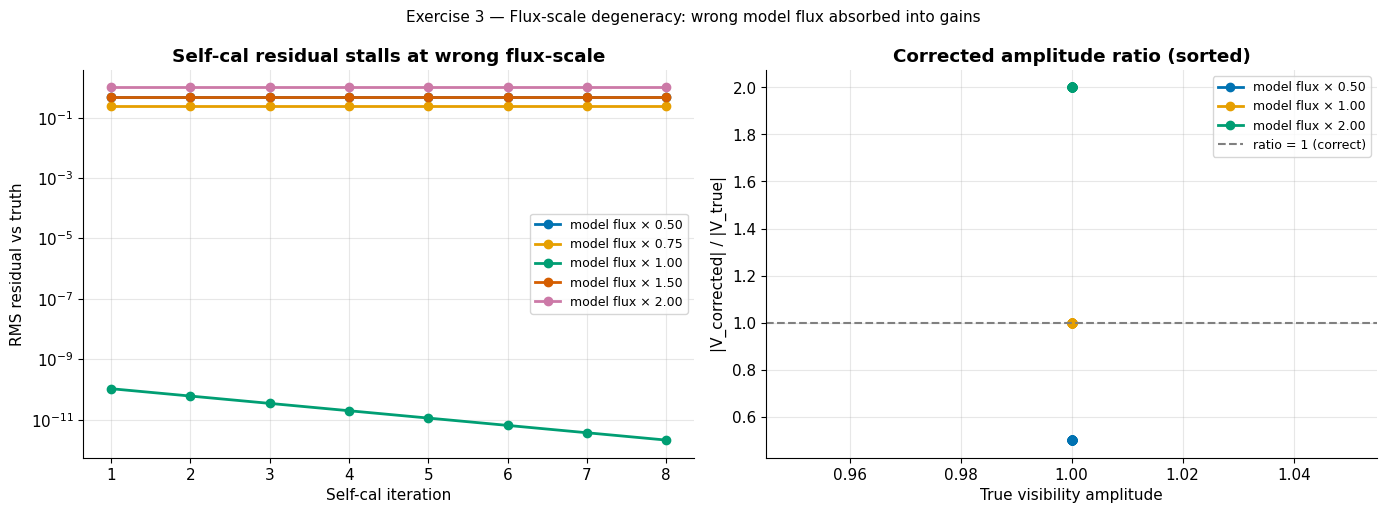

Final RMS residual (corrected vs true sky):
  × 0.50: RMS = 0.5000  (consistent with corrected ≈ 0.50×V_true → RMS ~ 0.50)
  × 0.75: RMS = 0.2500  (consistent with corrected ≈ 0.75×V_true → RMS ~ 0.25)
  × 1.00: RMS = 0.0000  (consistent with corrected ≈ 1.00×V_true → RMS ~ 0.00)
  × 1.50: RMS = 0.5000  (consistent with corrected ≈ 1.50×V_true → RMS ~ 0.50)
  × 2.00: RMS = 1.0000  (consistent with corrected ≈ 2.00×V_true → RMS ~ 1.00)

Blank model residuals (all 5 iter): ['2.2342', '2.2342', '2.2342', '2.2342', '2.2342']
(blank model: solver gets g_i = 1 always -> no correction -> residual stuck)


In [21]:
# Exercise 3 — self-cal with wrong model flux (flux-degeneracy demo).
# ── Scratch space ────────────────────────────────────────────────────────────
def run_selfcal_fixed_model(V_obs, V_true_ref, V_model_fixed, n_iter):
    """Run n_iter self-cal cycles with a FIXED model; return RMS residuals vs truth."""
    V_cur = V_obs.copy()
    residuals = []
    off_mask = ~np.eye(V_obs.shape[0], dtype=bool)
    for it in range(n_iter):
        g_it = solve_gains_stefcal(V_cur, V_model_fixed, n_iter=100)
        V_cur = V_cur / np.outer(g_it, np.conj(g_it))
        rms = float(np.sqrt(np.mean(np.abs(V_cur[off_mask] - V_true_ref[off_mask]) ** 2)))
        residuals.append(rms)
    return residuals, V_cur


# Sweep starting-model flux scale (S1 component only).
flux_scales = [0.5, 0.75, 1.0, 1.5, 2.0]
n_selfcal_ex3 = 8

colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

# Point-source self-cal (V_sc_true is the truth; V_sc_obs is the corrupted data).
V_pt = np.ones((N_SC, N_SC), dtype=complex)
np.fill_diagonal(V_pt, 0)
g_ex3 = rng.uniform(0.6, 1.8, N_SC) * np.exp(1j * rng.uniform(-np.pi, np.pi, N_SC))
V_pt_obs = apply_gains(V_pt, g_ex3)  # no noise for clarity

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

ax = axes[0]
final_rms = {}
for idx, fs in enumerate(flux_scales):
    V_model_fs = V_pt * fs
    np.fill_diagonal(V_model_fs, 0)
    res, V_cor_fs = run_selfcal_fixed_model(V_pt_obs, V_pt, V_model_fs, n_selfcal_ex3)
    final_rms[fs] = (res[-1], V_cor_fs)
    ax.semilogy(
        range(1, n_selfcal_ex3 + 1),
        res,
        "o-",
        color=colors[idx % len(colors)],
        lw=2,
        label=f"model flux × {fs:.2f}",
    )

ax.set_xlabel("Self-cal iteration")
ax.set_ylabel("RMS residual vs truth")
ax.set_title("Self-cal residual stalls at wrong flux-scale")
ax.legend(fontsize=9)

# Right panel: show what the corrected vis amplitude converges to.
ax2 = axes[1]
targets = [0.5, 1.0, 2.0]
for idx, fs in enumerate(targets):
    off_mask = ~np.eye(N_SC, dtype=bool)
    cor_amps = np.abs(final_rms[fs][1][off_mask])
    true_amps = np.abs(V_pt[off_mask])
    ax2.plot(
        np.sort(true_amps),
        np.sort(cor_amps) / np.sort(true_amps),
        "o-",
        color=colors[idx],
        lw=2,
        label=f"model flux × {fs:.2f}",
    )
ax2.axhline(1.0, color="grey", ls="--", lw=1.5, label="ratio = 1 (correct)")
ax2.set_xlabel("True visibility amplitude")
ax2.set_ylabel("|V_corrected| / |V_true|")
ax2.set_title("Corrected amplitude ratio (sorted)")
ax2.legend(fontsize=9)

fig.suptitle(
    "Exercise 3 — Flux-scale degeneracy: wrong model flux absorbed into gains", fontsize=11
)
fig.tight_layout()
plt.show()

print("Final RMS residual (corrected vs true sky):")
for fs in flux_scales:
    rms_val = final_rms[fs][0]
    expected_ratio = abs(fs - 1.0)  # RMS if corrected = fs * V_true
    print(
        f"  × {fs:.2f}: RMS = {rms_val:.4f}  "
        f"(consistent with corrected ≈ {fs:.2f}×V_true → RMS ~ {expected_ratio:.2f})"
    )

# Blank-model failure test.
V_blank = np.zeros((N_SC, N_SC), dtype=complex)
res_blank, _ = run_selfcal_fixed_model(V_pt_obs, V_pt, V_blank, 5)
print(f"\nBlank model residuals (all 5 iter): {[f'{r:.4f}' for r in res_blank]}")
print("(blank model: solver gets g_i = 1 always -> no correction -> residual stuck)")

<details><summary>Solution</summary>

**The flux-scale degeneracy:**

When the model flux is wrong (e.g. $\times 0.5$), `solve_gains_stefcal` finds
gains $\hat{g}_i$ such that $\hat{g}_i \hat{g}_j^* V^\mathrm{model}_{ij} \approx V^\mathrm{obs}_{ij}$.
Since $V^\mathrm{obs}_{ij} = g_i g_j^* V^\mathrm{true}_{ij}$ and
$V^\mathrm{model}_{ij} = 0.5\,V^\mathrm{true}_{ij}$, the solved gains absorb the
extra factor: $\hat{g}_i \approx \sqrt{2}\,g_i$.
Dividing out $\hat{g}$ then gives $V^\mathrm{corrected}_{ij} \approx 0.5\,V^\mathrm{true}_{ij}$ —
the corrected data has the **wrong flux scale**, but is internally self-consistent.

Expected results:

| Model flux | Final RMS vs truth | Corrected/true ratio |
|---|---|---|
| $\times 0.50$ | $\approx 0.5$ | $\approx 0.5$ |
| $\times 0.75$ | $\approx 0.25$ | $\approx 0.75$ |
| $\times 1.00$ | $\approx 10^{-10}$ | $\approx 1.00$ |
| $\times 1.50$ | $\approx 0.5$ | $\approx 1.50$ |
| $\times 2.00$ | $\approx 1.0$ | $\approx 2.00$ |

```python
# Verify: corrected vis with fs=0.5 is 0.5*V_true, not V_true.
V_model_half = V_pt * 0.5; np.fill_diagonal(V_model_half, 0)
_, V_cor_half = run_selfcal_fixed_model(V_pt_obs, V_pt, V_model_half, 8)
ratio = np.abs(V_cor_half[off_mask]) / np.abs(V_pt[off_mask])
print("mean |V_cor| / |V_true| for fs=0.5:", ratio.mean())   # ~ 0.5
```

**Blank model:** when the model is all zeros, StefCal's update formula
$g_i = \sum_j V^\mathrm{obs}_{ij} z_j^* / \sum_j |z_j|^2$
has $z_j = g_j V^\mathrm{model}_{ij} = 0$, so the denominator is zero and
`solve_gains_stefcal` returns unit gains — the data are unchanged and the
residual stalls at the uncalibrated level.

**Physical lesson:** self-calibration can only determine gain *ratios* and
*differential phases* — never the absolute flux scale.  In a real pipeline the
absolute flux scale is set once using an external calibrator (3C 286, Cas A,
etc.) and then the model flux is trusted.  Self-cal is used to track the
*changes* in gain with time and frequency, not to establish the overall scale.

</details>


## Recap

This chapter walked the complete practical calibration workflow:

| Step | Method | `jansky` helper |
|------|--------|-----------------|
| Forward model | $V^\mathrm{obs} = G V^\mathrm{true} G^\mathsf{H}$ | `apply_gains` |
| Gain calibration | StefCal iteration on a calibrator | `solve_gains_stefcal` |
| Point-source shortcut | Closed-form eigenvector solve | `solve_point_source_gains` |
| Bandpass calibration | Per-channel StefCal | `solve_gains_stefcal` (channel loop) |
| Self-calibration | Model → gain solve → correct → repeat | `solve_gains_stefcal` |
| Truth anchors | Gain-immune invariants | `closure_phase`, `closure_amplitude` |

Key take-aways:

- The **measurement equation** $V^\mathrm{obs}_{ij} = g_i V^\mathrm{true}_{ij} g_j^*$
  folds $N$ complex unknowns into $N(N-1)/2$ equations — the over-determination
  that makes calibration stable.
- An interferometer cannot recover the **absolute flux scale** or **global phase**
  without an external constraint; gain ratios and differential phases are all
  the data constrain.
- **Bandpass calibration** is gain-cal solved independently per channel; the
  solution is then interpolated or smoothed across the band.
- **Self-calibration** bootstraps the gain solution from the target source itself
  by iterating model updates and gain solves until convergence.
- **Closure phase** and **closure amplitude** are gain-immune throughout; they
  are the trustworthy observables when calibration is difficult or impossible.

## What's next

- **Chapter 12 — VLA imaging with CASA:** the same calibration workflow in a
  production pipeline — `gaincal`, `bandpass`, `applycal`, and `tclean` on a
  real measurement set.  The `jansky` helpers you used here are direct conceptual
  analogs of CASA's tasks.
- **Chapter 19 — The EHT & VLBI:** closure quantities doing the heavy lifting
  on a planet-scale sparse array where antenna-based calibration is imperfect.
- **Lab E — Linear Algebra for Calibration (notebook 35):** the full mathematical
  derivation of the eigenvector solve, SVD diagnostics, and regularisation —
  everything that underpins the helper calls above.
